# Lab 4

Temporal-Difference Learning

Task: Use Gymnasium’s CliffWalking-v0 environment. Implement two algorithms: SARSA and Q-learning, both using ε-greedy exploration. Your implementations should perform online updates after each env.step() call, not after complete episodes. Use NumPy arrays for Q-tables indexed by (state, action).

Structure your code to handle: (1) state observation from env.reset() and env.step(), (2) action selection using ε-greedy policy with np.argmax() for greedy actions and np.random.choice() for exploration, (3) Q-value updates using the appropriate TD target (SARSA uses next action, Q-learning uses np.max() over actions), (4) proper handling of terminal states (when terminated=True, next state value should be 0).

Run multiple seeds (at least 30) and plot learning curves showing sum of rewards per episode with 95% confidence intervals computed using NumPy statistical functions. Deeply analyze and document the behavioral differences between SARSA (safe path) and Q-learning (optimal but risky during learning). Create visualizations showing: (1) the learned Q-values as arrows in the grid, (2) sample trajectories from learned policies, (3) value function heatmaps using Matplotlib. Experiment with different step-size parameters (α) and exploration schedules (ε-decay). Include a comparison table of final performance, learning speed, and sample efficiency.

# Setting up Environment

In [22]:
# Libraries
import numpy as np
import pandas as pd
import gymnasium as gym
import matplotlib.pyplot as plt


In [3]:
# Checking gymnasium environments
envs = gym.envs.registry.keys()
print(list(envs))

['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v3', 'LunarLanderContinuous-v3', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v3', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v1', 'CliffWalkingSlippery-v1', 'Taxi-v3', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Reacher-v5', 'Pusher-v2', 'Pusher-v4', 'Pusher-v5', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedPendulum-v5', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedDoublePendulum-v5', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'HalfCheetah-v5', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Hopper-v5', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Swimmer-v5', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Walker2d-v5', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', 'Humanoid-v2', 'Humanoid-v3', 'Humanoid-

In [4]:
# Environment
ENV_NAME = "CliffWalking-v1"
N_SEEDS = 30
EPISODES = 500

env = gym.make(ENV_NAME)
n_states = env.observation_space.n
n_actions = env.action_space.n

### Environment Inspection

In [5]:
# Environment Inspection Function
def inspect_environment(env_name):

    env = gym.make(env_name)

    print(f"\nEnvironment: {env_name}")
    print("-"*40)

    obs_space = env.observation_space
    act_space = env.action_space

    print("Observation Space:", obs_space)
    print("Action Space:", act_space)

    # Inspecting space details
    if isinstance(obs_space, gym.spaces.Discrete):
        print("Observation Type: Discrete")
        print("Number of states:", obs_space.n)

    elif isinstance(obs_space, gym.spaces.Box):
        print("Observation Type: Continuous")
        print("Shape:", obs_space.shape)
        print("Bounds:", obs_space.low, obs_space.high)

    # Getting Action space details
    if isinstance(act_space, gym.spaces.Discrete):
        print("Action Type: Discrete")
        print("Number of actions:", act_space.n)

    elif isinstance(act_space, gym.spaces.Box):
        print("Action Type: Continuous")
        print("Shape:", act_space.shape)
        print("Bounds:", act_space.low, act_space.high)

    env.close()


In [6]:
# Inspecting Environment
inspect_environment(ENV_NAME)


Environment: CliffWalking-v1
----------------------------------------
Observation Space: Discrete(48)
Action Space: Discrete(4)
Observation Type: Discrete
Number of states: 48
Action Type: Discrete
Number of actions: 4


# ε-Greedy Policy

In [7]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(Q.shape[1])  # exploration component
    return np.argmax(Q[state]) # exploitation component

# SARSA (On-Policy, Online Updates)

In [8]:
def run_sarsa(seed, alpha=0.5, gamma=0.99, epsilon=0.1):
    np.random.seed(seed)
    env = gym.make(ENV_NAME)

    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = []

    for ep in range(EPISODES):
        state, _ = env.reset(seed=seed)
        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0
        terminated = False

        while not terminated:
            next_state, reward, terminated, truncated, _ = env.step(action)

            next_action = epsilon_greedy(Q, next_state, epsilon)

            # Terminal handling
            target = reward if terminated else reward + gamma * Q[next_state, next_action]

            Q[state, action] += alpha * (target - Q[state, action])

            state, action = next_state, next_action
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, np.array(rewards_per_episode)


# Q-Learning (Off-Policy, Online Updates)

In [9]:
def run_q_learning(seed, alpha=0.5, gamma=0.99, epsilon=0.1):
    np.random.seed(seed)
    env = gym.make(ENV_NAME)

    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = []

    for ep in range(EPISODES):
        state, _ = env.reset(seed=seed)

        total_reward = 0
        terminated = False

        while not terminated:
            action = epsilon_greedy(Q, state, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)

            # Terminal handling
            target = reward if terminated else reward + gamma * np.max(Q[next_state])

            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, np.array(rewards_per_episode)


# Experiments

### Multiple Seeds Function

In [10]:
def run_experiments(algo_fn, alpha=0.5, epsilon=0.1):
    all_rewards = []

    for seed in range(N_SEEDS):
        Q, rewards = algo_fn(seed, alpha=alpha, epsilon=epsilon)
        all_rewards.append(rewards)

    return np.array(all_rewards), Q

### SARSA (On-Policy, Online Updates)

In [11]:
sarsa_rewards, Q_sarsa = run_experiments(run_sarsa)

### Q-Learning (Off-Policy, Online Updates)

In [12]:
qlearn_rewards, Q_qlearn = run_experiments(run_q_learning)

### Learning Curves

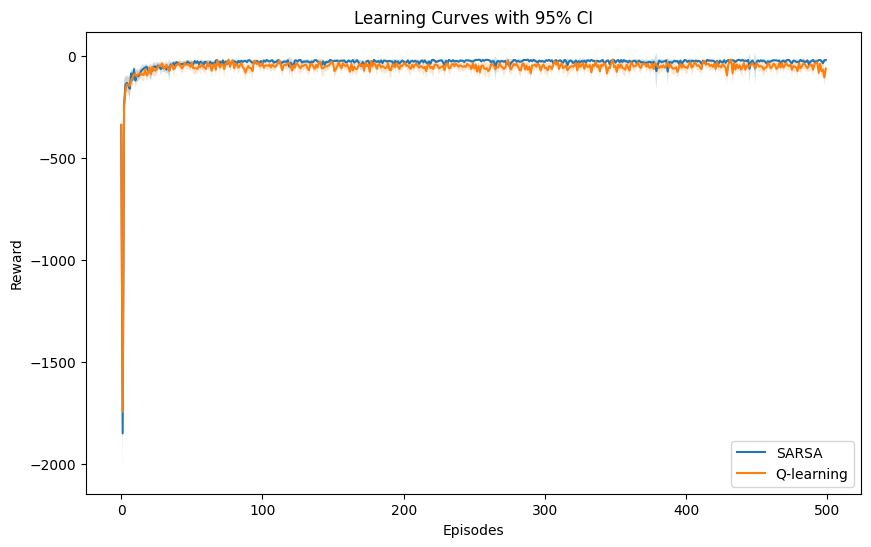

In [13]:
# Learning Curve Function
def plot_learning_curve(rewards, label):
    mean = rewards.mean(axis=0)
    std = rewards.std(axis=0)
    ci = 1.96 * std / np.sqrt(rewards.shape[0])

    plt.plot(mean, label=label)
    plt.fill_between(range(len(mean)), mean - ci, mean + ci, alpha=0.2)

# Plot
plt.figure(figsize=(10,6))
plot_learning_curve(sarsa_rewards, "SARSA")
plot_learning_curve(qlearn_rewards, "Q-learning")

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curves with 95% CI")
plt.legend()
plt.show()

### Policy Visualization

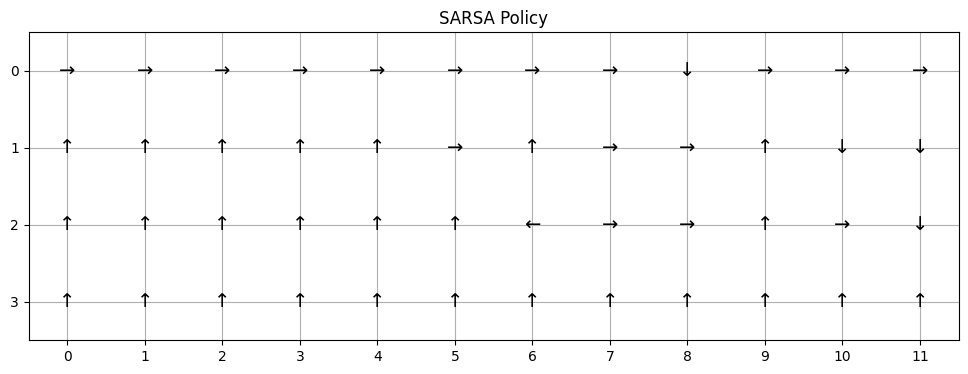

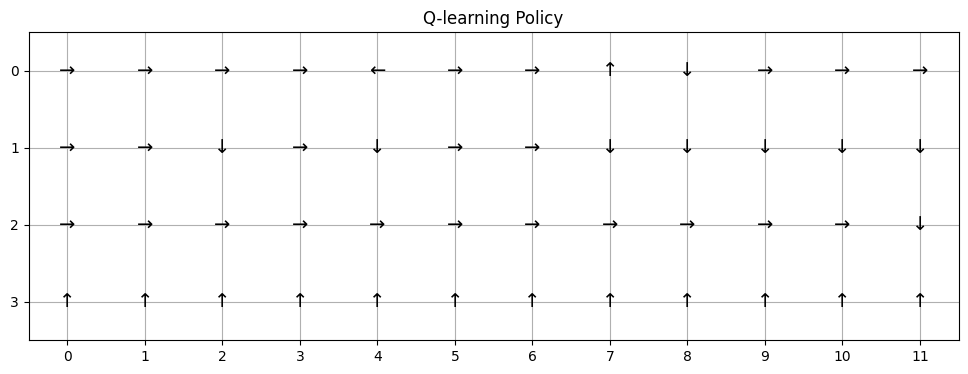

In [17]:
# Policy Plot Function
def plot_policy(Q, title):
    policy = np.argmax(Q, axis=1)
    grid = policy.reshape((4, 12))

    arrows = ['↑','→','↓','←']

    plt.figure(figsize=(12,4))

    for i in range(4):
        for j in range(12):
            plt.text(j, i, arrows[grid[i, j]],
                     ha='center', va='center',
                     fontsize=14, color='black')

    plt.xlim(-0.5, 11.5)
    plt.ylim(3.5, -0.5)

    plt.xticks(range(12))
    plt.yticks(range(4))
    plt.grid(True)

    plt.title(title)
    plt.show()

# Plot
plot_policy(Q_sarsa, "SARSA Policy")
plot_policy(Q_qlearn, "Q-learning Policy")


### Value Function Heatmap

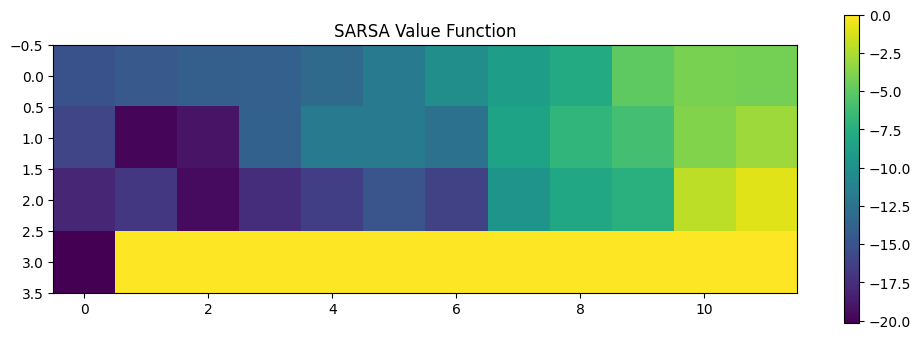

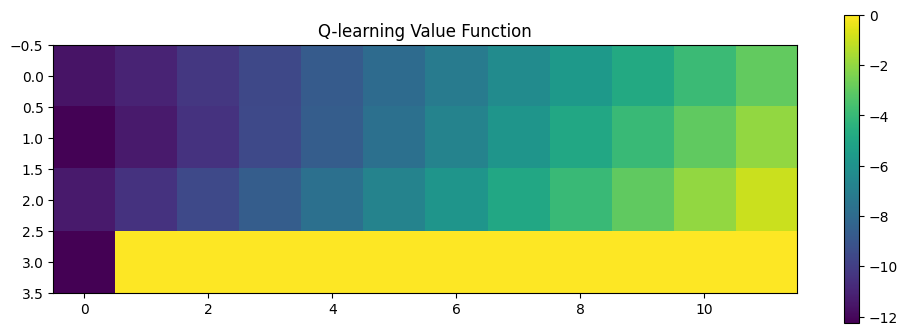

In [18]:
# Heatmap Function
def plot_value_function(Q, title):
    V = np.max(Q, axis=1).reshape((4, 12))

    plt.figure(figsize=(12,4))
    plt.imshow(V)
    plt.colorbar()
    plt.title(title)
    plt.show()

# Plot
plot_value_function(Q_sarsa, "SARSA Value Function")
plot_value_function(Q_qlearn, "Q-learning Value Function")



### Trajectories

In [19]:
# Trajectory Function
def trajectory(Q, max_steps=100):
    env = gym.make(ENV_NAME)
    state, _ = env.reset()

    traj = [state]
    visited = set([state])

    for _ in range(max_steps):
        max_val = np.max(Q[state])
        actions = np.where(Q[state] == max_val)[0]
        action = np.random.choice(actions)

        state, _, terminated, truncated, _ = env.step(action)
        traj.append(state)

        if terminated or truncated:
            break

        if state in visited:
            print("Loop detected.")
            break

        visited.add(state)

    return traj

print("SARSA trajectory:", trajectory(Q_sarsa))
print("Q-learning trajectory:", trajectory(Q_qlearn))


Loop detected.
SARSA trajectory: [36, 24, 12, 0, 1, 2, 3, 4, 5, 6, 7, 8, 20, 21, 9, 10, 11, 11]
Q-learning trajectory: [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]


# α Sensitivity Experiment

In [21]:
# Experiment
alphas = [0.1, 0.3, 0.5, 0.9]

results = {}
raw_results = {}

for a in alphas:
    rewards, _ = run_experiments(run_q_learning, alpha=a)
    raw_results[a] = rewards
    results[a] = rewards.mean(axis=0)


In [23]:
# Learning Speed Function
def learning_speed(rewards, threshold=-100):
    mean_curve = rewards.mean(axis=0)
    idx = np.where(mean_curve > threshold)[0]
    return idx[0] if len(idx) > 0 else np.nan

In [24]:
# Experiment Results
summary = []

for a, rewards in raw_results.items():
    summary.append({
        "alpha": a,
        "final_reward": rewards[:, -50:].mean(),
        "std_dev": rewards[:, -50:].std(),
        "learning_speed": learning_speed(rewards)
    })

df = pd.DataFrame(summary)
print(df)

   alpha  final_reward    std_dev  learning_speed
0    0.1    -46.833333  69.551594              42
1    0.3    -51.460000  72.683242              15
2    0.5    -52.206667  72.228849               9
3    0.9    -47.896000  69.116577               4


# ε-Decay Experiment

In [20]:
# Decay Function
def epsilon_decay(ep, min_eps=0.01, decay=0.995):
    return max(min_eps, decay * ep)


In [21]:
def run_experiments(algo_fn, alpha=0.5, epsilon=0.1):
    all_rewards = []

    for seed in range(N_SEEDS):
        Q, rewards = algo_fn(seed, alpha=alpha, epsilon=epsilon_decay(epsilon))
        all_rewards.append(rewards)

    return np.array(all_rewards), Q

In [22]:
sarsa_rewards, Q_sarsa = run_experiments(run_sarsa)

In [23]:
qlearn_rewards, Q_qlearn = run_experiments(run_q_learning)

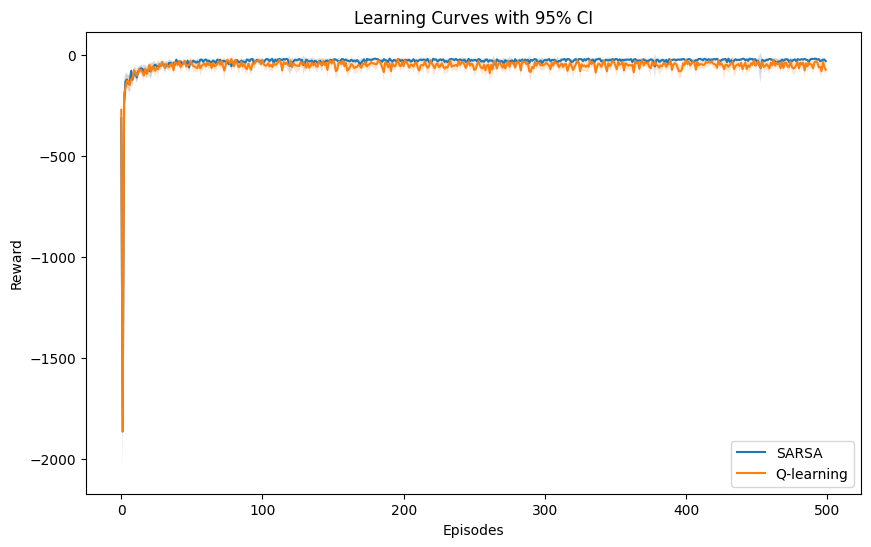

In [24]:
# Learning Curves
plt.figure(figsize=(10,6))
plot_learning_curve(sarsa_rewards, "SARSA")
plot_learning_curve(qlearn_rewards, "Q-learning")

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curves with 95% CI")
plt.legend()
plt.show()

In [1]:
# Policy Plot
plt.figure(figsize=(12, 4))
plot_policy(Q_sarsa, "SARSA Policy")
plot_policy(Q_qlearn, "Q-learning Policy")

NameError: name 'plt' is not defined

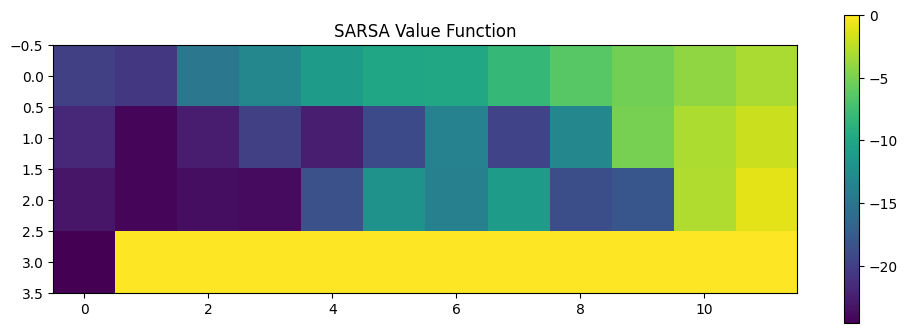

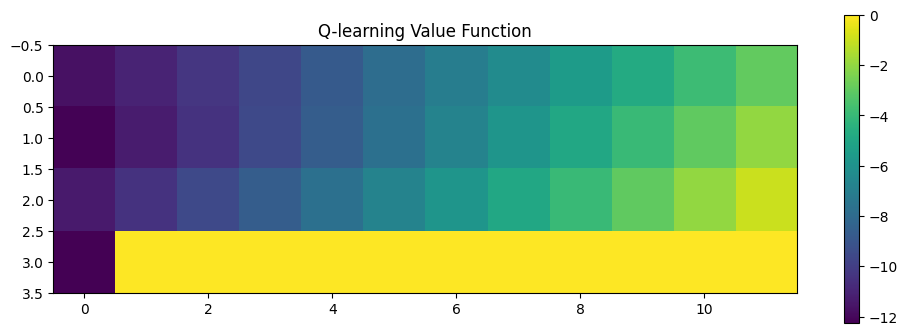

In [26]:
# Heatmap
plot_value_function(Q_sarsa, "SARSA Value Function")
plot_value_function(Q_qlearn, "Q-learning Value Function")
